# Model Wrapper Verification (Step 5 Gate)

**Goal:** Confirm that `Wav2Vec2MAML` correctly partitions parameters between the inner loop (`lm_head`) and outer loop (encoder), and that gradients flow through both.

**Checks:**
- Inner ∪ Outer = Total params (no leak, no gap)
- Inner ∩ Outer = ∅ (no duplication)
- Encoder `requires_grad=True` (Invariant I7)
- `lm_head` excluded from `get_outer_loop_params()` (Invariant I3)
- Meta-gradient shapes match encoder param shapes

**Visuals:**
- Donut chart: encoder vs lm_head param count split
- Bar chart: gradient L2-norm per encoder block after one dummy episode
- Table: per-module parameter counts

In [1]:
import sys, os
from pathlib import Path

# Make repo root importable
REPO = Path(os.path.abspath(".")).parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import torch
from models.wav2vec2_maml import Wav2Vec2MAML, load_processor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = Wav2Vec2MAML(device=device)
processor = load_processor()
print("Model loaded.")

Device: cuda


/home/theslender/anaconda3/envs/voicefl/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of the model checkpoint at facebook/wav2vec2-base-960h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded.


In [2]:
# ── Parameter partition audit ───────────────────────────────────────────────
inner_params = list(model.get_inner_loop_params())
outer_params = list(model.get_outer_loop_params())
all_params   = list(model.model.parameters())

n_inner = sum(p.numel() for p in inner_params)
n_outer = sum(p.numel() for p in outer_params)
n_total = sum(p.numel() for p in all_params)

print(f"Inner (lm_head) : {n_inner:>12,} params")
print(f"Outer (encoder) : {n_outer:>12,} params")
print(f"Total           : {n_total:>12,} params")
print()

inner_ids = {id(p) for p in inner_params}
outer_ids = {id(p) for p in outer_params}
all_ids   = {id(p) for p in all_params}

union_ok    = (inner_ids | outer_ids) == all_ids
overlap_ok  = len(inner_ids & outer_ids) == 0
req_grad_ok = all(p.requires_grad for p in outer_params)

print(f"[{'PASS' if union_ok   else 'FAIL'}] inner ∪ outer == all params")
print(f"[{'PASS' if overlap_ok else 'FAIL'}] inner ∩ outer == ∅")
print(f"[{'PASS' if req_grad_ok else 'FAIL'}] encoder requires_grad=True  (I7)")

assert union_ok,    "Param split is not exhaustive"
assert overlap_ok,  "Param split has overlaps"
assert req_grad_ok, "Encoder has frozen params (I7 violated)"

Inner (lm_head) :       24,608 params
Outer (encoder) :   94,371,712 params
Total           :   94,396,320 params

[PASS] inner ∪ outer == all params
[PASS] inner ∩ outer == ∅
[PASS] encoder requires_grad=True  (I7)


In [3]:
# ── Per-module breakdown table ──────────────────────────────────────────────
module_counts = []
for name, module in model.model.named_modules():
    direct = sum(p.numel() for p in module.parameters(recurse=False))
    if direct > 0:
        loop = "inner" if any(id(p) in inner_ids for p in module.parameters(recurse=False)) else "outer"
        module_counts.append((name or "(root)", direct, loop))

# Show top 20 by param count
module_counts.sort(key=lambda x: -x[1])
print(f"{'Module':<55} {'Params':>10}  Loop")
print("-" * 75)
for name, cnt, loop in module_counts[:20]:
    print(f"{name:<55} {cnt:>10,}  {loop}")

Module                                                      Params  Loop
---------------------------------------------------------------------------
wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight  4,718,720  outer
wav2vec2.encoder.layers.0.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.1.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.2.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.3.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.4.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.5.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.6.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.7.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.8.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.encoder.layers.9.feed_forward.intermediate_dense  2,362,368  outer
wav2vec2.enc

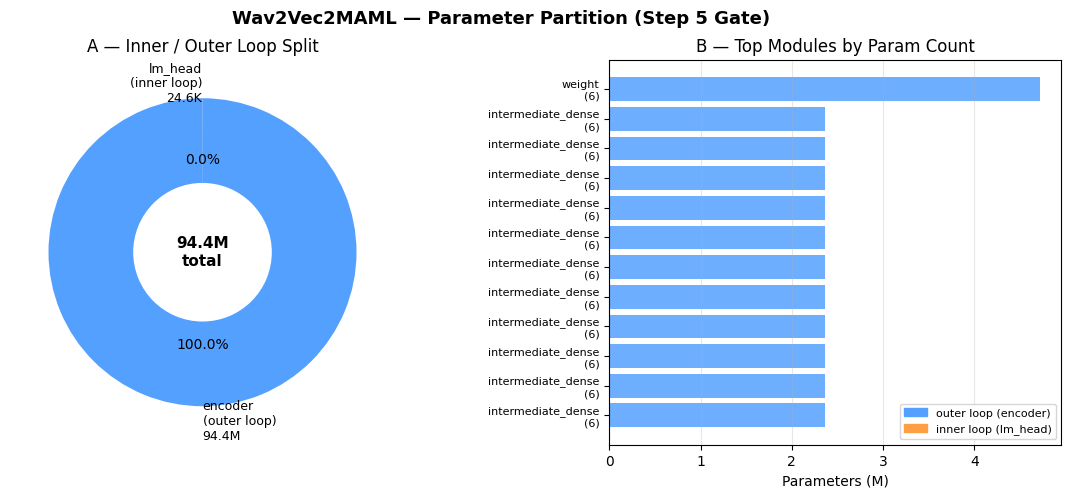

Saved: notebooks/data/model_param_split.png


In [4]:
# ── Figure 1: Parameter split donut chart ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
fig.suptitle("Wav2Vec2MAML — Parameter Partition (Step 5 Gate)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

# Panel A — donut chart
ax_a = fig.add_subplot(gs[0, 0])
sizes  = [n_inner, n_outer]
labels = [
    f"lm_head\n(inner loop)\n{n_inner/1e3:.1f}K",
    f"encoder\n(outer loop)\n{n_outer/1e6:.1f}M",
]
colors = ["#ff9f43", "#54a0ff"]
wedges, texts, autotexts = ax_a.pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9),
)
for at in autotexts:
    at.set_fontsize(10)
ax_a.set_title("A — Inner / Outer Loop Split")
ax_a.text(0, 0, f"{n_total/1e6:.1f}M\ntotal", ha="center", va="center", fontsize=11, fontweight="bold")

# Panel B — per-module bar chart (top 12)
ax_b = fig.add_subplot(gs[0, 1])
top = module_counts[:12]
names_b = [t[0].split(".")[-1] + f"\n({t[0].count('.')+1})".replace("(1)","") for t in top]
counts_b = [t[1] / 1e6 for t in top]
colors_b = ["#ff9f43" if t[2] == "inner" else "#54a0ff" for t in top]
bars_b = ax_b.barh(range(len(top)), counts_b[::-1], color=colors_b[::-1], alpha=0.85)
ax_b.set_yticks(range(len(top)))
ax_b.set_yticklabels(names_b[::-1], fontsize=8)
ax_b.set_xlabel("Parameters (M)")
ax_b.set_title("B — Top Modules by Param Count")
ax_b.grid(True, axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax_b.legend(handles=[
    Patch(color="#54a0ff", label="outer loop (encoder)"),
    Patch(color="#ff9f43", label="inner loop (lm_head)"),
], fontsize=8, loc="lower right")

save_dir = os.path.join(os.path.dirname(os.path.abspath("02_model_verify.ipynb")), "data")
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "model_param_split.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Saved: notebooks/data/model_param_split.png")

In [5]:
# ── Dummy meta-gradient pass ────────────────────────────────────────────────
# Build a tiny synthetic task (random features, empty label) to trigger one
# compute_meta_gradient() call and measure gradient norms per encoder block.

from data.task_sampler import VoiceTaskSampler, Task
from maml.engine import MAMLEngine

# Build a dummy 1-second, 16kHz clip (silence-ish noise)
dummy_audio = [torch.randn(16000) * 0.01]
dummy_label = ["HELLO"]

dummy_task = Task(
    support_audio=dummy_audio * 2,
    support_labels=dummy_label * 2,
    query_audio=dummy_audio * 2,
    query_labels=dummy_label * 2,
)

engine = MAMLEngine(model, processor, inner_steps=1, inner_lr=1e-4, device=device)
print("Running dummy meta-gradient pass...")
grads = engine.compute_meta_gradient(dummy_task)
print(f"Got {len(grads)} gradient tensors")

# Compute L2 norm per gradient tensor
grad_norms = [g.float().norm().item() for g in grads]

assert len(grads) == len(outer_params), "Gradient count mismatch"
print(f"[PASS] Gradient count matches outer_params ({len(grads)})")
print(f"Max  grad norm: {max(grad_norms):.4e}")
print(f"Mean grad norm: {sum(grad_norms)/len(grad_norms):.4e}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Running dummy meta-gradient pass...
Got 211 gradient tensors
[PASS] Gradient count matches outer_params (211)
Max  grad norm: 1.5286e+03
Mean grad norm: 6.4432e+01


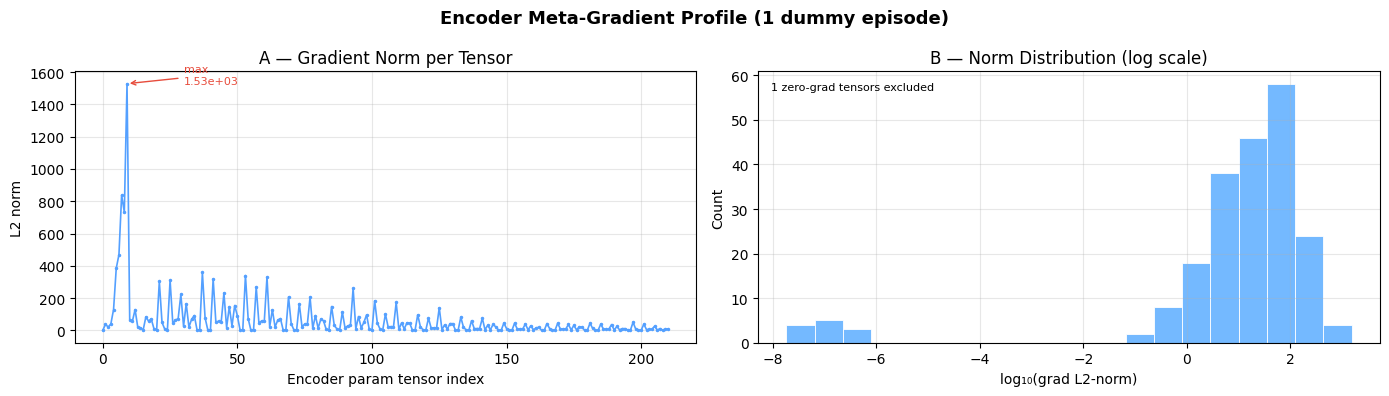

Saved: notebooks/data/model_grad_profile.png


In [6]:
# ── Figure 2: Gradient norm profile ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Encoder Meta-Gradient Profile (1 dummy episode)", fontsize=13, fontweight="bold")

# Panel A — grad norm per tensor index
ax_a = axes[0]
ax_a.plot(grad_norms, color="#54a0ff", linewidth=1.2, marker=".", markersize=3)
ax_a.set_xlabel("Encoder param tensor index")
ax_a.set_ylabel("L2 norm")
ax_a.set_title("A — Gradient Norm per Tensor")
ax_a.grid(True, alpha=0.3)

# Annotate max
max_idx = int(np.argmax(grad_norms))
ax_a.annotate(f"max\n{grad_norms[max_idx]:.2e}",
              xy=(max_idx, grad_norms[max_idx]),
              xytext=(max_idx + max(1, len(grad_norms) // 10), grad_norms[max_idx]),
              arrowprops=dict(arrowstyle="->", color="#e74c3c"),
              fontsize=8, color="#e74c3c")

# Panel B — log-scale histogram of grad norms
ax_b = axes[1]
nonzero = [v for v in grad_norms if v > 0]
if nonzero:
    log_norms = np.log10(nonzero)
    ax_b.hist(log_norms, bins=20, color="#74b9ff", edgecolor="white", linewidth=0.6)
    ax_b.set_xlabel("log₁₀(grad L2-norm)")
    ax_b.set_ylabel("Count")
    ax_b.set_title("B — Norm Distribution (log scale)")
    ax_b.grid(True, alpha=0.3)
    zero_count = len(grad_norms) - len(nonzero)
    ax_b.text(0.02, 0.96, f"{zero_count} zero-grad tensors excluded",
              transform=ax_b.transAxes, fontsize=8, va="top")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "model_grad_profile.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Saved: notebooks/data/model_grad_profile.png")

In [7]:
# ── Step 5 Gate summary ─────────────────────────────────────────────────────
print("=" * 50)
print("STEP 5 GATE SUMMARY")
print("=" * 50)
checks = [
    ("inner ∪ outer == all params",     union_ok),
    ("inner ∩ outer == ∅",              overlap_ok),
    ("encoder requires_grad=True (I7)", req_grad_ok),
    ("meta-grad count matches encoder", len(grads) == len(outer_params)),
]
all_ok = all(v for _, v in checks)
for label, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
print()
if all_ok:
    print("GATE PASSED — proceed to Step 6 (MAML engine gradient shapes)")
else:
    print("GATE FAILED — fix model wrapper before proceeding")
assert all_ok

STEP 5 GATE SUMMARY
  [PASS] inner ∪ outer == all params
  [PASS] inner ∩ outer == ∅
  [PASS] encoder requires_grad=True (I7)
  [PASS] meta-grad count matches encoder

GATE PASSED — proceed to Step 6 (MAML engine gradient shapes)
